In [1]:
import os
import yaml
from glob import glob

import matplotlib.pyplot as plt
import numpy as np

from mejiro.utils import util

# read configuration file
import mejiro
config_file = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'projects', 'roman_data_challenge', 'roman_data_challenge_rung_1.yaml')  # _unlabeled
# config_file = '/grad/bwedig/mejiro/projects/nancy/nancy.yaml'
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

In [4]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '04')

# 'lightweight' serialization writes .npz; 'full' writes .pkl. util.load_synthetic_image handles both.
serialization = config['synthetic_image'].get('serialization', 'full')
ext = '.npz' if serialization == 'lightweight' else '.pkl'

# Roman outputs are bucketed into sca* subdirectories; other instruments write flat.
images = sorted(glob(os.path.join(data_dir, 'sca*', f'SyntheticImage_*{ext}')))
# images = sorted(glob(os.path.join(data_dir, f'SyntheticImage_*{ext}')))  # non-Roman (no sca* subdirs)
print(f'Found {len(images)} {serialization} image(s) ({ext}) in {data_dir}')

Found 322521 lightweight image(s) (.npz) in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/04


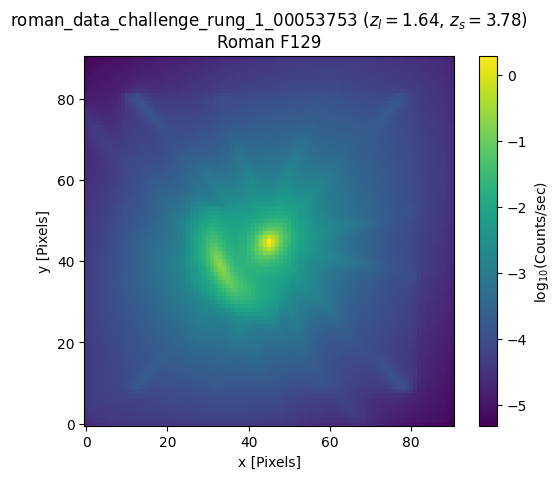

In [6]:
sample = util.load_synthetic_image(images[len(images) // 2])
sample.plot()

In [7]:
sample.data.shape

(91, 91)

/tmp/ipykernel_2649783/4221504935.py:8: RuntimeWarning: invalid value encountered in log10
  ax.flat[i].imshow(np.log10(sample.data), origin='lower')


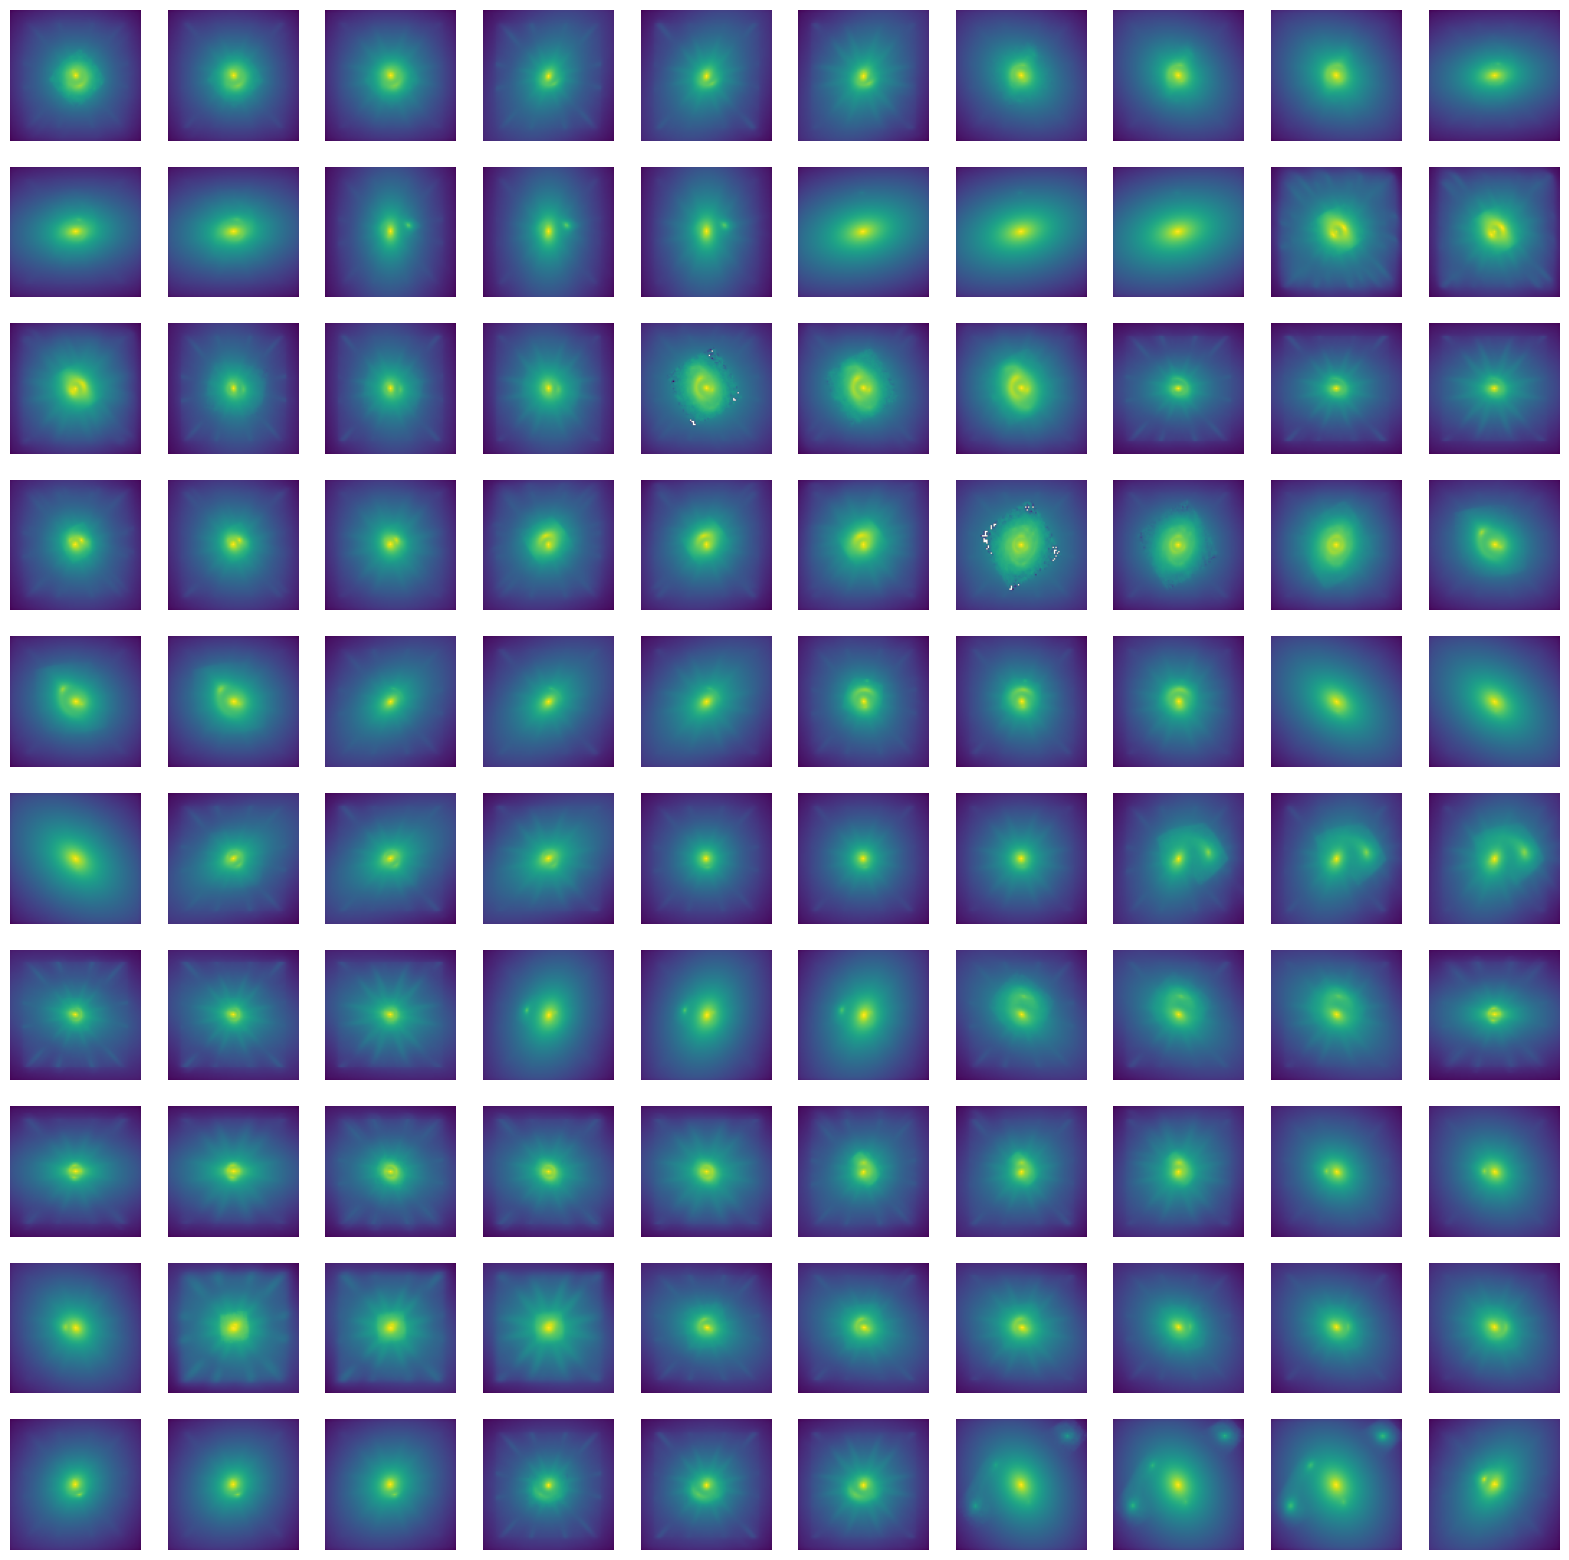

In [8]:
n = min(100, len(images))
ncols = 10
nrows = int(np.ceil(n / ncols))
_, ax = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))

for i in range(n):
    sample = util.load_synthetic_image(images[i])
    ax.flat[i].imshow(np.log10(sample.data), origin='lower')
    ax.flat[i].axis('off')
for j in range(n, nrows * ncols):  # blank any unused axes
    ax.flat[j].axis('off')

plt.savefig('figures/04/synthetic_images_grid.png', dpi=300)
plt.show()